In [1]:
import pandas as pd
df = pd.read_csv('../data/energy_features.csv', parse_dates=['timestamp'])
df.head()


,timestamp,solar_gen,wind_gen,demand,temp,humidity,wind_speed,hour,dayofweek,is_weekend
0,2024-01-01 00:00:00,0.0,402.84,9674.05,22.23,72.5,4.16,0,0,0
1,2024-01-01 01:00:00,0.0,535.44,9807.37,20.74,79.2,3.77,1,0,0
2,2024-01-01 02:00:00,0.0,1068.08,10010.68,20.91,81.6,6.47,2,0,0
3,2024-01-01 03:00:00,0.0,392.57,9745.17,21.18,78.4,4.14,3,0,0
4,2024-01-01 04:00:00,0.0,375.33,9914.20,18.35,82.5,4.15,4,0,0


In [2]:
df.isnull().sum()      # Ensure no missing values
df.describe()          # Summary stats for each feature


,timestamp,solar_gen,wind_gen,demand,temp,humidity,wind_speed,hour,dayofweek,is_weekend
count,8784,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000,8784.000000
mean,2024-07-01 23:30:00,535.146085,557.915443,9806.813363,25.983816,67.121710,4.003052,11.500000,2.986339,0.284153
min,2024-01-01 00:00:00,0.000000,69.860000,8464.400000,13.540000,41.300000,0.200000,0.000000,0.000000,0.000000
25%,2024-04-01 11:45:00,0.000000,284.910000,9489.130000,22.150000,60.700000,2.650000,5.750000,1.000000,0.000000
50%,2024-07-01 23:30:00,0.000000,495.390000,9845.975000,25.980000,67.900000,4.010000,11.500000,3.000000,0.000000
75%,2024-10-01 11:15:00,0.000000,777.470000,10164.302500,29.820000,73.700000,5.350000,17.250000,5.000000,1.000000
max,2024-12-31 23:00:00,5085.580000,1870.610000,11701.590000,38.660000,94.900000,8.980000,23.000000,6.000000,1.000000
std,NaN,1124.473460,329.791541,570.995202,4.875332,8.670117,1.765070,6.922581,2.003480,0.451036


In [3]:
df = df.fillna(method='ffill')


C:\Users\chatu\AppData\Local\Temp\ipykernel_29616\3984534036.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


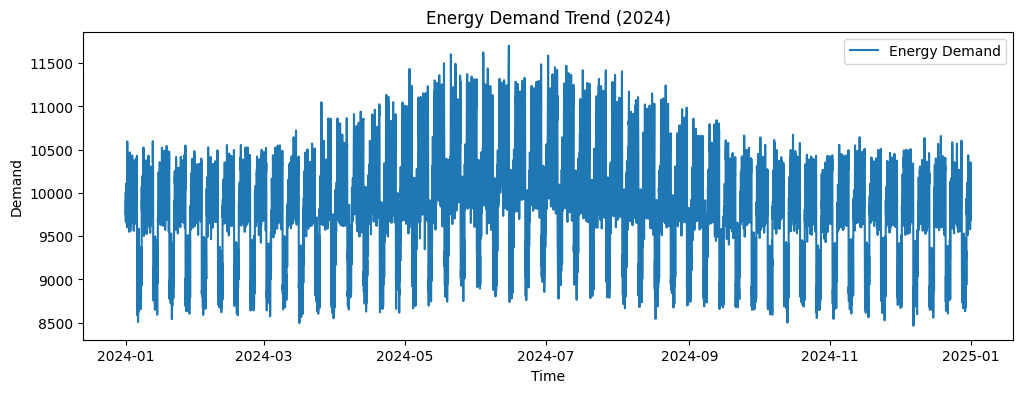

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], df['demand'], label='Energy Demand')
plt.title('Energy Demand Trend (2024)')
plt.xlabel('Time')
plt.ylabel('Demand')
plt.legend()
plt.show()
 

c:\Users\chatu\OneDrive\Attachments\Desktop\EnergyForecasting\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
16:28:05 - cmdstanpy - INFO - Chain [1] start processing
16:28:06 - cmdstanpy - INFO - Chain [1] done processing
c:\Users\chatu\OneDrive\Attachments\Desktop\EnergyForecasting\venv\lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


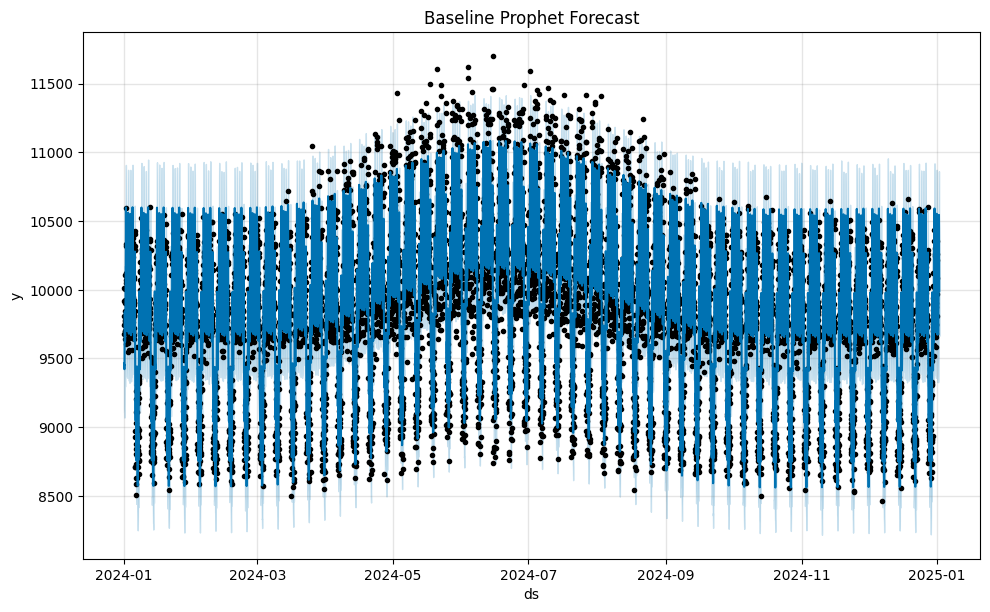

In [5]:
from prophet import Prophet

# Prophet expects columns ds (datetime) and y (target)
data = df[['timestamp', 'demand']].rename(columns={'timestamp': 'ds', 'demand': 'y'})

model = Prophet()
model.fit(data)

# Predict the next 24 hours
future = model.make_future_dataframe(periods=24, freq='H')
forecast = model.predict(future)

# Plot forecast
model.plot(forecast)
plt.title('Baseline Prophet Forecast')
plt.show()


In [6]:
from sklearn.metrics import mean_squared_error
import numpy as np

actual = data['y'][-24:]               # Last 24 real points
predicted = forecast['yhat'][-24:]     # Prophet’s next 24 forecasts

rmse = np.sqrt(mean_squared_error(actual, predicted))
print("Baseline RMSE:", rmse)


Baseline RMSE: 188.39695631684663
